# Gamma Gradients

This notebook generates a green gradient signifying the difference between gamma encoded and not.

new pipeline: painter_Tessellated_custom_fill_3950020432936449483_no_brush_sample_true_rgba8unorm


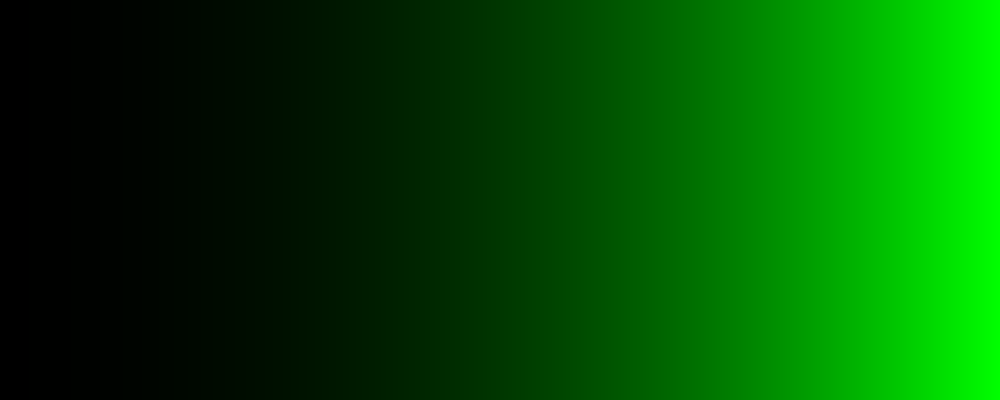

new pipeline: painter_Tessellated_custom_fill_10263099226769712530_no_brush_sample_true_rgba8unorm


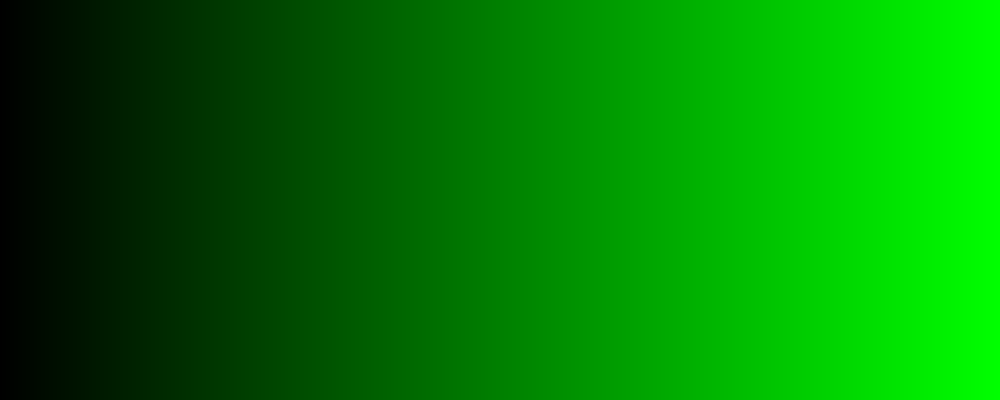

In [2]:
import brushcue
from IPython.display import Image, display

OUTPUT_LINEAR_PATH = "/home/dito/dev/monorepo/writing/graphics/chapters/numbers/assets/green_gradient_linear.png"
OUTPUT_GAMMA_PATH = "/home/dito/dev/monorepo/writing/graphics/chapters/numbers/assets/green_gradient_gamma.png"

ctx = brushcue.Context()

def gradient_painter(fill: brushcue.Graph) -> brushcue.Graph:
    painter = brushcue.painter_new()
    painter = brushcue.painter_add_rectangle_with_render_style(
        painter,
        brushcue.point2f_from_components(500, 0),
        brushcue.vector2f_constant(1000, 400),
        0,
        brushcue.render_style_fill_only(fill),
        brushcue.transform2_to_list(brushcue.transform2_identity())
    )
    composition = brushcue.composition_painter(painter)
    return composition

fill_gamma = brushcue.fill_custom(
    """
    let gamma_encoded = canvas_position.x / 1000.0;
    let linear = select(
        pow((gamma_encoded + 0.055) / 1.055, 2.4),
        gamma_encoded / 12.92,
        gamma_encoded <= 0.04045,
    );
    return vec4<f32>(0.0, linear, 0.0, 1.0);
    """,
    "",
    brushcue.dictionary_create()
)
fill_linear = brushcue.fill_custom(
    "return vec4<f32>(0, canvas_position.x / 1000, 0, 1);",
    "",
    brushcue.dictionary_create()
)

painter = gradient_painter(fill_gamma)
image_bytes = painter.execute(ctx).as_composition().to_image_bytes(ctx)
with open(OUTPUT_GAMMA_PATH, "wb") as f:
    f.write(image_bytes)
display(Image(OUTPUT_GAMMA_PATH))
painter = gradient_painter(fill_linear)
image_bytes = painter.execute(ctx).as_composition().to_image_bytes(ctx)
with open(OUTPUT_LINEAR_PATH, "wb") as f:
    f.write(image_bytes)
display(Image(OUTPUT_LINEAR_PATH))